In [80]:
#setup 

import torch
import random
import matplotlib.pyplot as plt
import torchvision
from torch import nn
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import save_image, make_grid
from torchvision.datasets import MNIST
import os

if not os.path.exists('./dc_img'):
    os.mkdir('./dc_img')
    
print ("setup done")

setup done


In [81]:
#helper functions
def to_img(x):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    x = x.view(x.size(0), 1, 28, 28)
    return x

In [82]:
#hyperparameters
num_epochs = 10
batch_size = 128
learning_rate = 1e-3

In [83]:
#Data loading
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

dataset = MNIST('./data', transform=img_transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print("Number of batches:", len(dataloader))



Number of batches: 469


In [84]:
#add noise to the image
def add_noise(img, sigma=0.2):
    noise = torch.randn_like(img) * sigma
    noisy_img = img + noise
    noisy_img = torch.clamp(noisy_img, -1., 1.)  # keep same range
    return noisy_img

In [85]:
#Model definition
class autoencoder(nn.Module):
    def __init__(self):
        super(autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=3, padding=1),  # b, 16, 10, 10
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),  # b, 16, 5, 5
            nn.Conv2d(16, 8, 3, stride=2, padding=1),  # b, 8, 3, 3
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=1)  # b, 8, 2, 2
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 3, stride=2),  # b, 16, 5, 5
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 5, stride=3, padding=1),  # b, 8, 15, 15
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 2, stride=2, padding=1),  # b, 1, 28, 28
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

print ("model defined")


model defined


In [86]:
#Model and optimizer
model = autoencoder()

# load model if exists, after finalizing on the model, this can be used.
if os.path.exists("conv_autoencoder.pth"):
    model.load_state_dict(torch.load("conv_autoencoder.pth"))
    print("Loaded previous model weights")
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,
                             weight_decay=1e-5)

Loaded previous model weights


In [87]:
#visualize of noise and denoising.
# using noise of 0.3, strong noise to test quality of reconstruction
def visualize(model, dataloader, epoch, sigma=0.3):
    img, _ = next(iter(dataloader))

    noisy_img = add_noise(img, sigma)

    # no_grad (forward pass only,since we are using the resulted weights)
    with torch.no_grad():
        output = model(noisy_img)

    orig = to_img(img)
    noisy = to_img(noisy_img)
    recon = to_img(output)

    plt.figure(figsize=(9,3))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(orig[0][0], cmap='gray') #plot first image in batch

    plt.subplot(1,3,2)
    plt.title(f"Noisy σ={sigma}")
    plt.imshow(noisy[0][0], cmap='gray')

    plt.subplot(1,3,3)
    plt.title("Reconstructed")
    plt.imshow(recon[0][0], cmap='gray')

    plt.suptitle(f"Epoch {epoch}")
    plt.show()

In [ ]:
#detect the last run number from dc_img folder so that images saved in it are based on run number and repective epoch within the run.
save_path = "./dc_img"

existing_files = os.listdir(save_path)

run_ids = []

for f in existing_files:
    if "run" in f:
        try:
            run_num = int(f.split("run")[1].split("_")[0])
            run_ids.append(run_num)
        except:
            pass

run_id = max(run_ids) + 1 if run_ids else 1

print(f"Starting Run {run_id}")

Starting Run 3


In [89]:
#save locally a grid of size 9X8 where first 3 rows are original images, later 3 rows are their respective noisy versions, later 3 rows are their respective reconstruced versions
#images are randomly selected from same batch
def save_comparison_grid(img, noisy_img, output, epoch, save_path="./dc_img"):
    
    num_cols = 8
    num_imgs = num_cols * 3   #24 images → 3 rows per category

    #random selection (same indices for all 3 types)
    indices = torch.randperm(img.size(0))[:num_imgs]

    orig_imgs = img[indices]
    noisy_imgs = noisy_img[indices]
    recon_imgs = output[indices]

    #convert to [0,1]
    orig_imgs = to_img(orig_imgs)
    noisy_imgs = to_img(noisy_imgs)
    recon_imgs = to_img(recon_imgs)

    #stack: orig below it is noisy below it is recon
    grid_imgs = torch.cat([orig_imgs, noisy_imgs, recon_imgs], dim=0)

    #create grid
    grid = make_grid(grid_imgs, nrow=num_cols)

    #save
    save_image(grid, f"{save_path}/grid_run{run_id}_epoch_{epoch}.png")

In [90]:
#saving the loss of cuurrent run so that in next run it gets appended to the new loss in the loss curve in order to show a representative learning flow
loss_file = "losses.pt"

if os.path.exists(loss_file):
    losses = torch.load(loss_file)
    print(f"Loaded previous losses: {len(losses)} points")
else:
    losses = [] 

Loaded previous losses: 10 points


Epoch [1/10], Loss: 0.1061


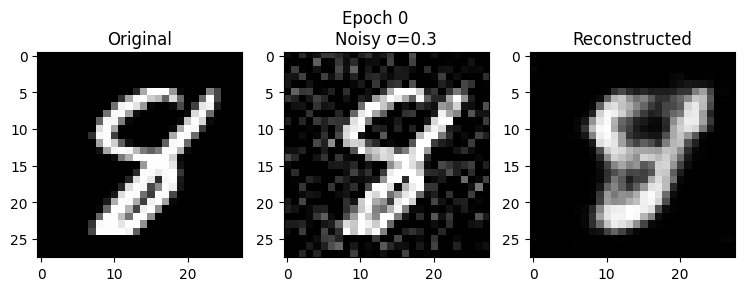

Epoch [2/10], Loss: 0.1057
Epoch [3/10], Loss: 0.1054
Epoch [4/10], Loss: 0.1052
Epoch [5/10], Loss: 0.1049
Epoch [6/10], Loss: 0.1048
Epoch [7/10], Loss: 0.1047
Epoch [8/10], Loss: 0.1042
Epoch [9/10], Loss: 0.1043
Epoch [10/10], Loss: 0.1042


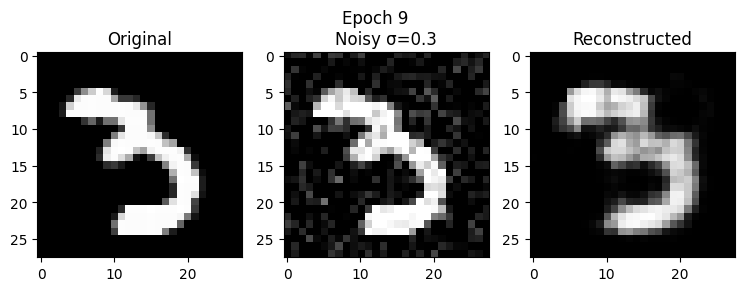

In [91]:
#Training loop

for epoch in range(num_epochs):
    total_loss = 0
    for data in dataloader:
        img, _ = data
        img = Variable(img)
        sigma = random.choice([0.1, 0.2, 0.3])
        noisy_img = add_noise(img, sigma=sigma)
        # ===================forward=====================
        output = model(noisy_img)
        loss = criterion(output, img)
        # ===================backward====================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    # ===================log========================
    
    avg_loss = total_loss / len(dataloader) #avergae loss per epoch
    losses.append(avg_loss) #store average loss per epoch for plotting later
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}") #print the avg loss for each epoch
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        visualize(model, dataloader, epoch) # visualize every 10 epochs
        save_comparison_grid(img, noisy_img, output, epoch) #save grid of original, noisy and reconstructed images every 10 epochs
        

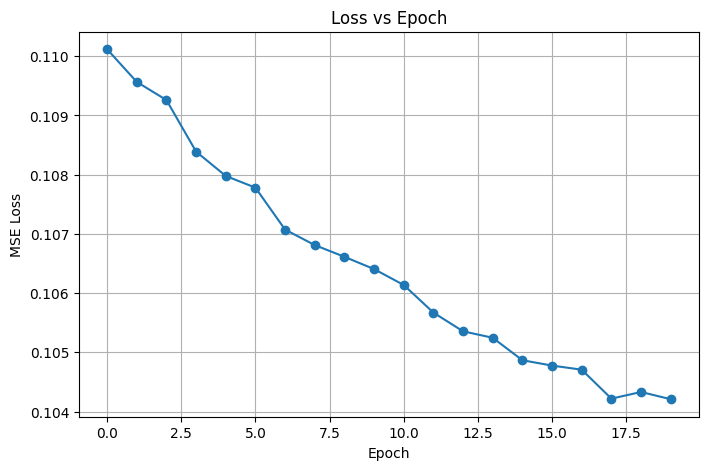

In [92]:
#plotting the loss curve
plt.figure(figsize=(8,5))
plt.plot(losses, marker='o')
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

In [93]:
#save model
torch.save(model.state_dict(), './conv_autoencoder.pth')
print("Saved updated model weights")
#save losses
torch.save(losses, loss_file)
print("Saved updated loss history")

Saved updated model weights
Saved updated loss history
